# 01 Linear Regression — First Principles

> **Status:** 🟡 In Progress | **Phase:** 1 | **Prerequisites:** Linear Algebra, Calculus

**Goal.** Build, verify, and stress-test linear regression from scratch — closed-form
(normal equations) and gradient descent — on synthetic and real data.

---

## Prerequisites

- See [theory.md](theory.md) for all derivations (notation, MSE, gradient, Hessian, convexity, normal equations, hat matrix, SVD pseudoinverse, Gauss–Markov)
- Required foundations:
  - [Linear Algebra: Projections](../../foundations/linear_algebra/projections_least_squares.ipynb)
  - [Calculus: Gradient Descent](../../foundations/calculus_optimization/gradient_descent.ipynb)

In [1]:
import random

import matplotlib.pyplot as plt
import numpy as np

%load_ext autoreload
%autoreload 2

SEED = 42
random.seed(SEED)
rng = np.random.default_rng(SEED)

plt.rcParams["figure.dpi"] = 90

## 1. Problem Setup — WHY

We have a set of continuous features and we want to predict a continuous target value.
The simplest relationship to assume is a straight line (or a hyperplane in higher
dimensions). Let's build intuition with a toy house-price dataset.

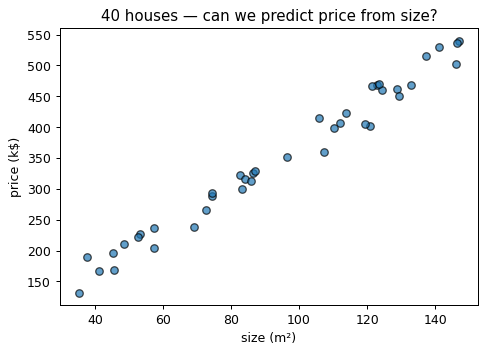

In [2]:
# Toy dataset: house size (m²) vs price (k$)
true_slope, true_intercept = 3.5, 20.0
x_houses = rng.uniform(30, 150, size=40)
noise_houses = rng.normal(0, 25, size=x_houses.size)
y_houses = true_slope * x_houses + true_intercept + noise_houses

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(x_houses, y_houses, alpha=0.7, edgecolor="k")
ax.set_xlabel("size (m²)")
ax.set_ylabel("price (k$)")
ax.set_title("40 houses — can we predict price from size?")
plt.show()

### Many lines could fit — which one is "best"?

A line is defined by **slope** (how steep) and **intercept** (where it crosses zero).
For each house, the **residual** is the gap between predicted and actual price.
A good line makes those gaps small *on average*.

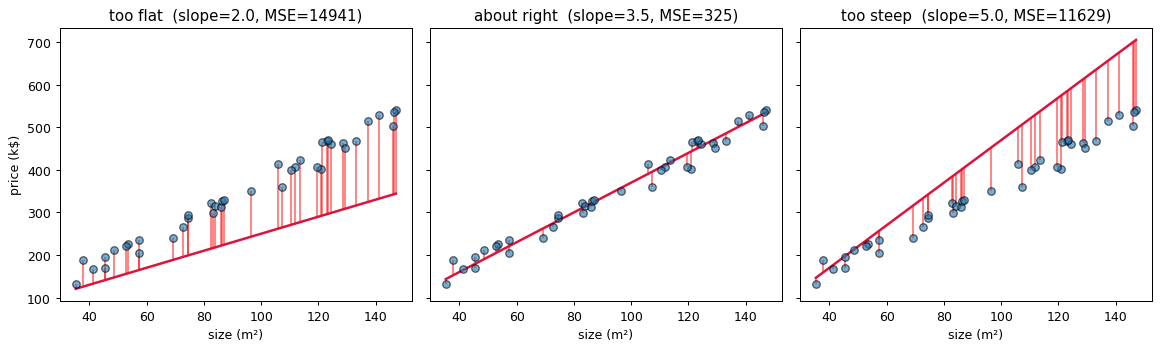

In [3]:
xs = np.linspace(x_houses.min(), x_houses.max(), 100)
candidates = [(2.0, 50, "too flat"), (3.5, 20, "about right"), (5.0, -30, "too steep")]

fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)
for ax, (m, b, label) in zip(axes, candidates):
    y_hat = m * x_houses + b
    mse_val = np.mean((y_houses - y_hat) ** 2)
    ax.scatter(x_houses, y_houses, alpha=0.6, edgecolor="k", zorder=3)
    ax.plot(xs, m * xs + b, color="crimson", lw=2, zorder=2)
    ax.vlines(x_houses, np.minimum(y_houses, y_hat), np.maximum(y_houses, y_hat),
              color="red", alpha=0.5, zorder=1)
    ax.set_title(f"{label}  (slope={m}, MSE={mse_val:.0f})")
    ax.set_xlabel("size (m²)")
axes[0].set_ylabel("price (k$)")
plt.tight_layout()
plt.show()

### The loss landscape

Fix the intercept at 20 and sweep the slope. The error traces a smooth **bowl** with
exactly one bottom — a convex quadratic (proved in [theory.md](theory.md) §5.4).

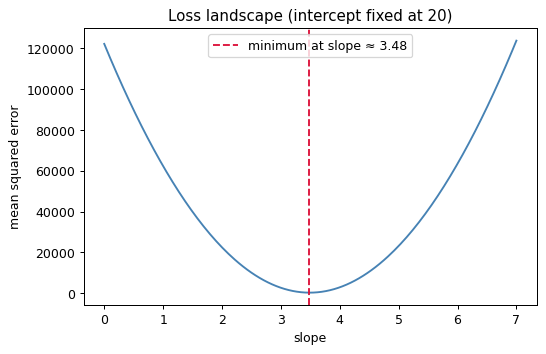

In [4]:
slopes = np.linspace(0, 7, 200)
errors = [np.mean((y_houses - (m * x_houses + 20)) ** 2) for m in slopes]
best = slopes[np.argmin(errors)]

fig, ax = plt.subplots(figsize=(6.5, 4))
ax.plot(slopes, errors, color="steelblue")
ax.axvline(best, color="crimson", ls="--", label=f"minimum at slope ≈ {best:.2f}")
ax.set_xlabel("slope")
ax.set_ylabel("mean squared error")
ax.set_title("Loss landscape (intercept fixed at 20)")
ax.legend()
plt.show()

### When a straight line stops working

Two situations break the picture above:
- **Outliers** — one bad point can drag the whole line.
- **Non-linear truth** — a straight line just cannot follow a curve.

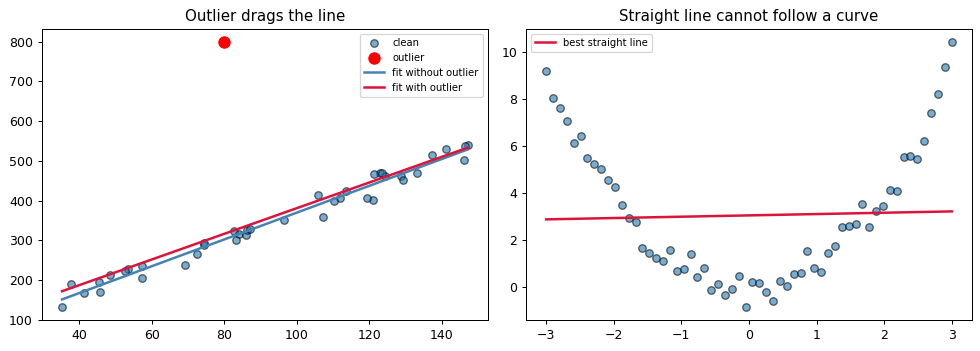

In [5]:
# (a) outlier
x_out = np.append(x_houses, [80])
y_out = np.append(y_houses, [800])  # one wildly wrong reading

# (b) non-linear truth
x_nl = np.linspace(-3, 3, 60)
y_nl = x_nl ** 2 + rng.normal(0, 0.5, size=x_nl.size)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

m1, b1 = np.polyfit(x_houses, y_houses, 1)
m2, b2 = np.polyfit(x_out, y_out, 1)
axes[0].scatter(x_houses, y_houses, alpha=0.6, edgecolor="k", label="clean")
axes[0].scatter([80], [800], color="red", s=80, label="outlier", zorder=3)
axes[0].plot(xs, m1 * xs + b1, color="steelblue", lw=2, label="fit without outlier")
axes[0].plot(xs, m2 * xs + b2, color="crimson", lw=2, label="fit with outlier")
axes[0].set_title("Outlier drags the line")
axes[0].legend(fontsize=8)

m3, b3 = np.polyfit(x_nl, y_nl, 1)
axes[1].scatter(x_nl, y_nl, alpha=0.6, edgecolor="k")
axes[1].plot(x_nl, m3 * x_nl + b3, color="crimson", lw=2, label="best straight line")
axes[1].set_title("Straight line cannot follow a curve")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

## 2. Mathematical Core — WHAT

The model assumes $\hat{y} = X\theta$. We minimise the Mean Squared Error:

$$L(\theta) = \frac{1}{n} \|X\theta - y\|^2$$

Two solution paths:
1. **Normal Equation (Closed-form):** $\hat{\theta} = (X^\top X)^{-1} X^\top y$
2. **Gradient Descent (Iterative):** $\theta_{k+1} = \theta_k - \eta \frac{2}{n} X^\top (X \theta_k - y)$

See [theory.md](theory.md) for full derivations.

In [6]:
# Verify the normal equation on 1D synthetic data
from ml_first_principles.data_utils import generate_regression_data

X_1d, y_1d = generate_regression_data(n_samples=50, n_features=1, noise=1.5, random_state=42)
X_b = np.c_[np.ones((X_1d.shape[0], 1)), X_1d]  # Add bias column

theta_best = np.linalg.lstsq(X_b, y_1d, rcond=None)[0]
print(f"Normal Equation weights (via lstsq): {theta_best}")

# Cross-check with explicit formula
theta_explicit = np.linalg.solve(X_b.T @ X_b, X_b.T @ y_1d)
print(f"Normal Equation weights (explicit):  {theta_explicit}")
print(f"Agreement: {np.allclose(theta_best, theta_explicit)}")

Normal Equation weights (via lstsq): [0.98459401 1.34009228]
Normal Equation weights (explicit):  [0.98459401 1.34009228]
Agreement: True


## 3. Solution Method — HOW

### 3.1 Gradient descent on the OLS bowl

For linear regression, the gradient is (theory.md §5.2):

$$\nabla L(\theta) = \frac{2}{n} X^\top (X\theta - y)$$

Each step costs $\Theta(np)$ — versus the $\Theta(np^2 + p^3)$ normal-equation route.

Estimated intercept = 1.0123   (true = 1.0)
Estimated slope     = 1.9990   (true = 2.0)
Final MSE           = 0.269937


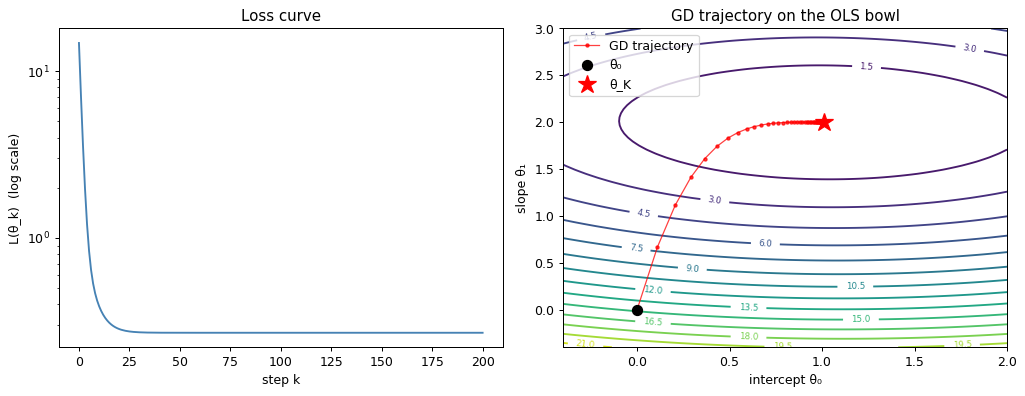

In [7]:
# Generate 2-parameter problem: y = 2x + 1 + noise
n_gd = 100
x_gd = rng.uniform(-3, 3, size=n_gd)
noise_gd = rng.normal(0, 0.5, size=n_gd)
y_gd = 2.0 * x_gd + 1.0 + noise_gd

X_gd = np.column_stack([np.ones(n_gd), x_gd])

def mse(theta, X=X_gd, y=y_gd):
    return float(np.mean((X @ theta - y) ** 2))

def grad_mse(theta, X=X_gd, y=y_gd):
    return (2.0 / len(y)) * X.T @ (X @ theta - y)

# Run GD
theta_gd = np.zeros(2)
eta = 0.05
trajectory = [theta_gd.copy()]
losses_gd = [mse(theta_gd)]
for _ in range(200):
    theta_gd = theta_gd - eta * grad_mse(theta_gd)
    trajectory.append(theta_gd.copy())
    losses_gd.append(mse(theta_gd))
trajectory = np.array(trajectory)

print(f"Estimated intercept = {theta_gd[0]:.4f}   (true = 1.0)")
print(f"Estimated slope     = {theta_gd[1]:.4f}   (true = 2.0)")
print(f"Final MSE           = {losses_gd[-1]:.6f}")

# Two-panel plot: loss curve + trajectory on the 2-D OLS bowl
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.5))

axes[0].plot(losses_gd, color="steelblue")
axes[0].set_yscale("log")
axes[0].set_xlabel("step k")
axes[0].set_ylabel("L(θ_k)  (log scale)")
axes[0].set_title("Loss curve")

t0_grid = np.linspace(-0.4, 2.0, 80)
t1_grid = np.linspace(-0.4, 3.0, 80)
T0, T1 = np.meshgrid(t0_grid, t1_grid)
Theta_grid = np.stack([T0.ravel(), T1.ravel()], axis=0)
L_flat = np.mean((X_gd @ Theta_grid - y_gd[:, None]) ** 2, axis=0)
L_grid = L_flat.reshape(T0.shape)

cs = axes[1].contour(T0, T1, L_grid, levels=15, cmap="viridis")
axes[1].clabel(cs, inline=True, fontsize=7, fmt="%.1f")
axes[1].plot(trajectory[:, 0], trajectory[:, 1], "r-o", markersize=2.5, lw=1, alpha=0.75,
             label="GD trajectory")
axes[1].plot(trajectory[0, 0], trajectory[0, 1], "ko", markersize=8, label="θ₀")
axes[1].plot(trajectory[-1, 0], trajectory[-1, 1], "r*", markersize=15, label="θ_K")
axes[1].set_xlabel("intercept θ₀")
axes[1].set_ylabel("slope θ₁")
axes[1].set_title("GD trajectory on the OLS bowl")
axes[1].legend(loc="upper left")

plt.tight_layout()
plt.show()

### 3.2 Learning rate sweep

The convergence interval is $0 < \eta < 2/L_{\text{smooth}}$ (theory.md §11).
Three regimes: too small (slow), just right (fast monotonic), too large (diverges).

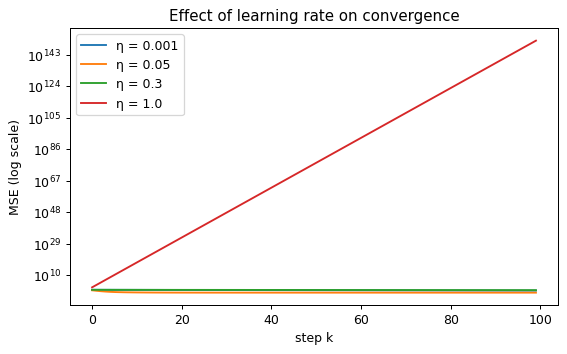

σ₁(X)             = 18.2473
L_smooth           = 6.6593
Convergence bound  = 0.3003
  → η = 1.0 is above the boundary, so its curve diverges.


In [8]:
etas = [0.001, 0.05, 0.3, 1.0]
n_steps_lr = 100

plt.figure(figsize=(7, 4))
for eta_ in etas:
    theta_lr = np.zeros(2)
    curve = []
    for _ in range(n_steps_lr):
        theta_lr = theta_lr - eta_ * grad_mse(theta_lr)
        curve.append(mse(theta_lr))
    plt.plot(curve, label=f"η = {eta_}")
plt.yscale("log")
plt.xlabel("step k")
plt.ylabel("MSE (log scale)")
plt.title("Effect of learning rate on convergence")
plt.legend()
plt.show()

# Theoretical convergence bound
sigma1 = np.linalg.svd(X_gd, compute_uv=False)[0]
L_smooth = (2.0 / n_gd) * sigma1 ** 2
print(f"σ₁(X)             = {sigma1:.4f}")
print(f"L_smooth           = {L_smooth:.4f}")
print(f"Convergence bound  = {2.0 / L_smooth:.4f}")
print("  → η = 1.0 is above the boundary, so its curve diverges.")

### 3.3 Stochastic variants

When the full gradient ($\Theta(np)$ per step) is too expensive, use a mini-batch estimate.

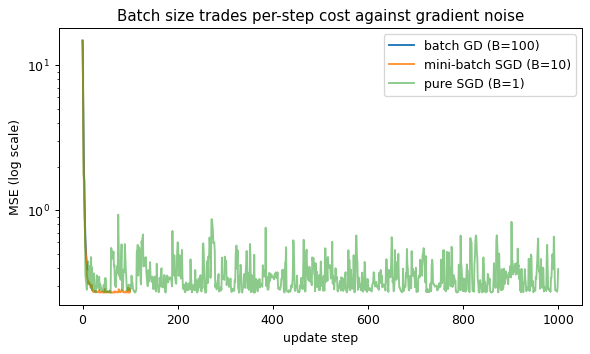

In [9]:
def run_sgd(batch_size, n_passes, eta_sgd, seed=0):
    rng_local = np.random.default_rng(seed)
    theta = np.zeros(2)
    curve = [mse(theta)]
    for _ in range(n_passes):
        order = rng_local.permutation(n_gd)
        for start in range(0, n_gd, batch_size):
            idx = order[start:start + batch_size]
            X_b_, y_b_ = X_gd[idx], y_gd[idx]
            g = (2.0 / len(idx)) * X_b_.T @ (X_b_ @ theta - y_b_)
            theta = theta - eta_sgd * g
            curve.append(mse(theta))
    return theta, np.array(curve)

theta_batch, loss_batch = run_sgd(batch_size=n_gd, n_passes=10, eta_sgd=0.05)
theta_mini,  loss_mini  = run_sgd(batch_size=10,   n_passes=10, eta_sgd=0.05)
theta_sgd_,  loss_sgd_  = run_sgd(batch_size=1,    n_passes=10, eta_sgd=0.05)

plt.figure(figsize=(7.5, 4))
plt.plot(loss_batch, label=f"batch GD (B={n_gd})")
plt.plot(loss_mini,  label="mini-batch SGD (B=10)", alpha=0.85)
plt.plot(loss_sgd_,  label="pure SGD (B=1)",        alpha=0.55)
plt.yscale("log")
plt.xlabel("update step")
plt.ylabel("MSE (log scale)")
plt.title("Batch size trades per-step cost against gradient noise")
plt.legend()
plt.show()

## 4. Implementation — BUILD

Two from-scratch implementations, then a reusable library import.

### 4.1 Closed-form OLS class

In [10]:
from scipy import stats


class LinearRegressionOLS:
    """Closed-form OLS via np.linalg.lstsq, sklearn-style API.

    Adds a bias column internally. After fit(), attributes include:
      coef_, intercept_, theta_, sigma2_, se_, t_, p_value_, r2_.
    """

    def fit(self, X, y):
        n, p = X.shape
        X_design = np.column_stack([np.ones(n), X])
        theta, *_ = np.linalg.lstsq(X_design, y, rcond=None)
        self.theta_     = theta
        self.intercept_ = float(theta[0])
        self.coef_      = theta[1:]

        # Residual diagnostics (theory.md §9)
        y_hat = X_design @ theta
        resid = y - y_hat
        rss   = float(resid @ resid)
        dof   = n - (p + 1)
        self.sigma2_ = rss / dof
        XtX_inv      = np.linalg.inv(X_design.T @ X_design)
        self.se_     = np.sqrt(self.sigma2_ * np.diag(XtX_inv))
        self.t_      = theta / self.se_
        self.p_value_= 2.0 * (1.0 - stats.t.cdf(np.abs(self.t_), df=dof))
        tss          = float(np.sum((y - y.mean()) ** 2))
        self.r2_     = 1.0 - rss / tss
        self._n, self._p = n, p + 1
        return self

    def predict(self, X):
        return self.intercept_ + X @ self.coef_

### 4.2 Gradient descent class

Uses internal feature standardisation to reduce the condition number (theory.md §11).

In [11]:
class LinearRegressionGD:
    """Batch gradient descent for OLS, with internal feature standardisation."""

    def __init__(self, lr=0.1, n_iter=500, tol=1e-8):
        self.lr     = lr
        self.n_iter = n_iter
        self.tol    = tol

    def fit(self, X, y):
        n, p = X.shape
        self.mu_    = X.mean(axis=0)
        self.sigma_ = X.std(axis=0)
        self.sigma_[self.sigma_ == 0] = 1.0
        Xs = (X - self.mu_) / self.sigma_
        Xd = np.column_stack([np.ones(n), Xs])

        theta = np.zeros(p + 1)
        self.loss_history_ = []
        for k in range(self.n_iter):
            resid = Xd @ theta - y
            grad  = (2.0 / n) * Xd.T @ resid
            theta = theta - self.lr * grad
            loss  = float(np.mean((Xd @ theta - y) ** 2))
            self.loss_history_.append(loss)
            if np.linalg.norm(grad) < self.tol:
                break

        # Map standardised weights back to original scale
        b_std, w_std = theta[0], theta[1:]
        self.coef_      = w_std / self.sigma_
        self.intercept_ = float(b_std - np.sum(w_std * self.mu_ / self.sigma_))
        self.theta_     = np.r_[self.intercept_, self.coef_]
        self.loss_history_ = np.array(self.loss_history_)
        return self

    def predict(self, X):
        return self.intercept_ + X @ self.coef_

### 4.3 Verify both on synthetic data

In [12]:
# Generate controlled data with known truth
rng_synth = np.random.default_rng(SEED)
n_synth, p_synth = 500, 4
X_synth = rng_synth.normal(size=(n_synth, p_synth))
theta_true = rng_synth.uniform(-3, 3, size=p_synth + 1)
eps_synth = rng_synth.normal(0, 1.0, size=n_synth)
y_synth = theta_true[0] + X_synth @ theta_true[1:] + eps_synth

# Fit both
ols = LinearRegressionOLS().fit(X_synth, y_synth)
gd  = LinearRegressionGD(lr=0.1, n_iter=500).fit(X_synth, y_synth)

print(f"theta_true       = {theta_true}")
print(f"theta_hat (OLS)  = {ols.theta_}")
print(f"theta_hat (GD)   = {gd.theta_}")
print(f"max |GD - OLS|   = {np.max(np.abs(gd.theta_ - ols.theta_)):.2e}")
print(f"R² (OLS)         = {ols.r2_:.4f}")
print()
print("Per-coefficient inference (OLS):")
print(f"{'j':>2}  {'theta_hat':>10}  {'SE':>8}  {'t':>8}  {'p_value':>10}")
for j in range(ols._p):
    print(f"{j:>2}  {ols.theta_[j]:>10.4f}  {ols.se_[j]:>8.4f}  {ols.t_[j]:>8.2f}  {ols.p_value_[j]:>10.2e}")

theta_true       = [-2.74592332 -0.33037343  0.28192673 -2.1195406  -0.98228502]
theta_hat (OLS)  = [-2.74244505 -0.4095924   0.27180447 -2.14783679 -0.93233506]
theta_hat (GD)   = [-2.74244505 -0.4095924   0.27180447 -2.14783679 -0.93233506]
max |GD - OLS|   = 3.26e-09
R² (OLS)         = 0.8618

Per-coefficient inference (OLS):
 j   theta_hat        SE         t     p_value
 0     -2.7424    0.0459    -59.74    0.00e+00
 1     -0.4096    0.0477     -8.58    2.22e-16
 2      0.2718    0.0436      6.23    1.00e-09
 3     -2.1478    0.0450    -47.78    0.00e+00
 4     -0.9323    0.0471    -19.79    0.00e+00


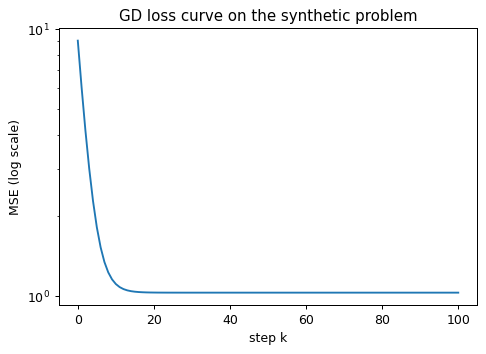

In [13]:
plt.figure(figsize=(6, 4))
plt.plot(gd.loss_history_)
plt.yscale("log")
plt.xlabel("step k")
plt.ylabel("MSE (log scale)")
plt.title("GD loss curve on the synthetic problem")
plt.show()

### 4.4 Using the reusable library implementation

The `src/ml_first_principles` package provides a tested `LinearRegression` class
that implements both solvers.

In [14]:
from ml_first_principles.linear_models import LinearRegression

# 1. Using Normal Equation
model_normal = LinearRegression(solver='normal')
model_normal.fit(X_synth, y_synth)
print(f"Library Normal: intercept = {model_normal.intercept_:.4f}, coef = {model_normal.coef_}")

# 2. Using Gradient Descent
model_gd = LinearRegression(solver='gd', lr=0.1, max_iter=500)
model_gd.fit(X_synth, y_synth)
print(f"Library GD:     intercept = {model_gd.intercept_:.4f}, coef = {model_gd.coef_}")

# Verify agreement
assert np.allclose(model_normal.intercept_, ols.intercept_, atol=1e-6)
assert np.allclose(model_normal.coef_, ols.coef_, atol=1e-6)
print("✓ Library normal matches our OLS implementation!")

Library Normal: intercept = -2.7424, coef = [-0.4095924   0.27180447 -2.14783679 -0.93233506]
Library GD:     intercept = -2.7424, coef = [-0.40958939  0.27180473 -2.14783477 -0.93233705]
✓ Library normal matches our OLS implementation!


## 5. Library Comparison

Cross-check all implementations against scikit-learn.

In [15]:
from sklearn.linear_model import LinearRegression as SklearnLR

skl = SklearnLR().fit(X_synth, y_synth)
skl_theta = np.r_[skl.intercept_, skl.coef_]

rows = [
    ("truth",      theta_true),
    ("ours: OLS",  ols.theta_),
    ("ours: GD",   gd.theta_),
    ("sklearn",    skl_theta),
]
header = "  ".join(f"{'w'+str(i):>9}" for i in range(len(theta_true)))
print(f"{'method':<12}  {header}")
for name, vec in rows:
    vals = "  ".join(f"{v: 9.4f}" for v in vec)
    print(f"{name:<12}  {vals}")

print()
print(f"max |ours OLS - sklearn| = {np.max(np.abs(ols.theta_ - skl_theta)):.2e}")
print(f"max |ours GD  - sklearn| = {np.max(np.abs(gd.theta_  - skl_theta)):.2e}")

method               w0         w1         w2         w3         w4
truth           -2.7459    -0.3304     0.2819    -2.1195    -0.9823
ours: OLS       -2.7424    -0.4096     0.2718    -2.1478    -0.9323
ours: GD        -2.7424    -0.4096     0.2718    -2.1478    -0.9323
sklearn         -2.7424    -0.4096     0.2718    -2.1478    -0.9323

max |ours OLS - sklearn| = 2.22e-15
max |ours GD  - sklearn| = 3.26e-09


### 5.1 Real data — the diabetes regression benchmark

442 patients, 10 features, continuous disease-progression target.

In [16]:
import time
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

data = load_diabetes()
X_full, y_full = data.data, data.target
X_train, X_test, y_train, y_test = train_test_split(
    X_full, y_full, test_size=0.2, random_state=SEED
)
print(f"train / test split: {X_train.shape[0]} / {X_test.shape[0]} samples")

estimators = {
    "ours: OLS":  LinearRegressionOLS(),
    "ours: GD":   LinearRegressionGD(lr=0.01, n_iter=5000),
    "sklearn":    SklearnLR(),
}

baseline_pred = np.full_like(y_test, y_train.mean(), dtype=float)
results = [{"name": "mean baseline",
            "rmse_te": float(np.sqrt(mean_squared_error(y_test, baseline_pred))),
            "r2_te":   float(r2_score(y_test, baseline_pred))}]

for name, est in estimators.items():
    t0 = time.perf_counter()
    est.fit(X_train, y_train)
    fit_time = time.perf_counter() - t0
    y_pred_te = est.predict(X_test)
    results.append({
        "name":     name,
        "rmse_te":  float(np.sqrt(mean_squared_error(y_test, y_pred_te))),
        "r2_te":    float(r2_score(y_test, y_pred_te)),
    })

print(f"{'method':<14} {'RMSE_test':>12} {'R2_test':>9}")
for r in results:
    print(f"{r['name']:<14} {r['rmse_te']:>12.2f} {r['r2_te']:>9.4f}")

train / test split: 353 / 89 samples
method            RMSE_test   R2_test
mean baseline         73.22   -0.0120
ours: OLS             53.85    0.4526
ours: GD              53.76    0.4545
sklearn               53.85    0.4526


## 6. Experiments and Failures — VERIFY

### 6.1 Monte Carlo CI coverage

If the 95 % confidence interval (theory.md §9.4) is built correctly, it should cover
the true parameter in ~95 % of resamples.

In [17]:
n_mc, p_mc = 200, 3
theta_mc = np.array([1.5, -2.0, 0.7])
sigma_mc = 0.5

# Fixed design
X_mc = np.column_stack([np.ones(n_mc), rng.normal(size=n_mc), rng.normal(size=n_mc)])

M = 5000
alpha = 0.05
t_crit = stats.t.ppf(1 - alpha / 2, df=n_mc - p_mc)
XtX_inv_mc = np.linalg.inv(X_mc.T @ X_mc)
diag_V = np.diag(XtX_inv_mc)

covered = np.zeros(p_mc, dtype=int)
for m in range(M):
    eps = rng.normal(0, sigma_mc, size=n_mc)
    y_mc = X_mc @ theta_mc + eps
    theta_hat = XtX_inv_mc @ X_mc.T @ y_mc
    resid = y_mc - X_mc @ theta_hat
    s2 = resid @ resid / (n_mc - p_mc)
    se = np.sqrt(s2 * diag_V)
    lo = theta_hat - t_crit * se
    hi = theta_hat + t_crit * se
    covered += ((lo <= theta_mc) & (theta_mc <= hi)).astype(int)

print(f"target coverage  = {1 - alpha:.2f}")
print(f"empirical coverage per coefficient (M = {M}):")
for j in range(p_mc):
    print(f"  theta_{j}:  {covered[j] / M:.4f}")

target coverage  = 0.95
empirical coverage per coefficient (M = 5000):
  theta_0:  0.9512
  theta_1:  0.9494
  theta_2:  0.9480


### 6.2 R² decomposition: TSS = ESS + RSS

In [18]:
eps_r2 = rng.normal(0, sigma_mc, size=n_mc)
y_r2 = X_mc @ theta_mc + eps_r2
theta_hat_r2 = np.linalg.solve(X_mc.T @ X_mc, X_mc.T @ y_r2)
y_hat_r2 = X_mc @ theta_hat_r2
y_bar = y_r2.mean()

TSS = float(np.sum((y_r2 - y_bar) ** 2))
ESS = float(np.sum((y_hat_r2 - y_bar) ** 2))
RSS = float(np.sum((y_r2 - y_hat_r2) ** 2))
R2  = 1 - RSS / TSS

print(f"TSS         = {TSS:.4f}")
print(f"ESS         = {ESS:.4f}")
print(f"RSS         = {RSS:.4f}")
print(f"ESS + RSS   = {ESS + RSS:.4f}   (should equal TSS)")
print(f"R²          = {R2:.4f}")
print(f"Identity holds within {abs(ESS + RSS - TSS):.2e}")

TSS         = 940.0533
ESS         = 884.0465
RSS         = 56.0068
ESS + RSS   = 940.0533   (should equal TSS)
R²          = 0.9404
Identity holds within 1.14e-12


### 6.3 Assumption diagnostics

Two standard plots to check the Gauss–Markov assumptions (theory.md §12):
- **Residual vs. fitted:** homoscedasticity → horizontal band.
- **QQ-plot:** normality → points on the diagonal.

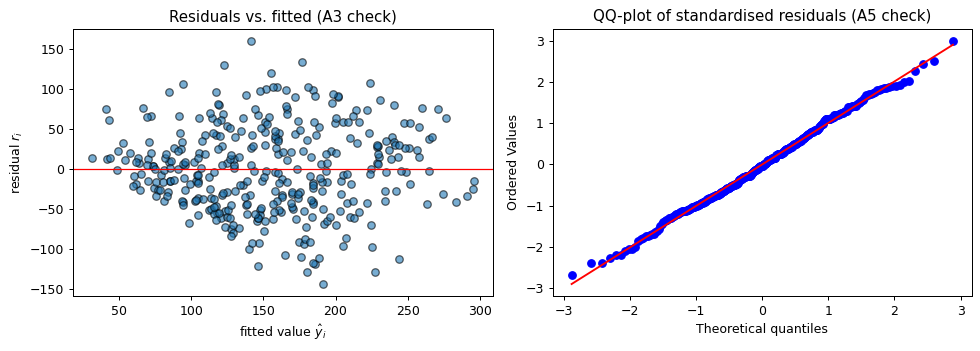

residual mean     = -0.0000   (should be ~0)
residual std      = 53.5588
Shapiro-Wilk p    = 0.6398   (small => non-normal)


In [19]:
ols_diag = LinearRegressionOLS().fit(X_train, y_train)
y_pred_diag = ols_diag.predict(X_train)
resid_diag = y_train - y_pred_diag
resid_std = resid_diag / np.std(resid_diag)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].scatter(y_pred_diag, resid_diag, alpha=0.6, edgecolor="k")
axes[0].axhline(0, color="red", lw=1)
axes[0].set_xlabel("fitted value $\\hat y_i$")
axes[0].set_ylabel("residual $r_i$")
axes[0].set_title("Residuals vs. fitted (A3 check)")

stats.probplot(resid_std, dist="norm", plot=axes[1])
axes[1].set_title("QQ-plot of standardised residuals (A5 check)")

plt.tight_layout()
plt.show()

print(f"residual mean     = {resid_diag.mean():.4f}   (should be ~0)")
print(f"residual std      = {resid_diag.std():.4f}")
print(f"Shapiro-Wilk p    = {stats.shapiro(resid_diag).pvalue:.4f}   (small => non-normal)")

### 6.4 Failure case — multicollinearity

When two features are nearly identical, $(X^\top X)^{-1}$ has huge diagonal entries
and coefficient standard errors explode.

In [20]:
n_col = 200
x1_col = rng.normal(size=n_col)
x2_col = x1_col + rng.normal(0, 0.01, size=n_col)  # nearly identical to x1
X_col = np.column_stack([x1_col, x2_col])
y_col = 3.0 * x1_col + 2.0 * x2_col + rng.normal(0, 0.5, size=n_col)

ols_col = LinearRegressionOLS().fit(X_col, y_col)

print("true theta   = [intercept≈0, 3.0, 2.0]")
print(f"theta_hat    = {ols_col.theta_}")
print(f"std errors   = {ols_col.se_}")
print(f"condition #  = {np.linalg.cond(np.c_[np.ones((n_col, 1)), X_col]):.0f}")
print()
print("Note: individual coefficients are wildly imprecise")
print("even though the prediction y_hat ≈ 5·x is stable.")

true theta   = [intercept≈0, 3.0, 2.0]
theta_hat    = [-0.04397383  6.0313716  -1.01023494]
std errors   = [0.03416671 3.41071375 3.41272266]
condition #  = 182

Note: individual coefficients are wildly imprecise
even though the prediction y_hat ≈ 5·x is stable.


## 7. Connections

- **Prerequisites:** [Linear Algebra](../../foundations/linear_algebra/README.md), [Calculus & Optimization](../../foundations/calculus_optimization/README.md)
- **Theory:** [theory.md](theory.md) — all derivations live there
- **Related Topics:** [Polynomial Regression](theory.md#10-polynomial-regression-extension), [03 Regularization](../03_regularization/README.md) (Ridge, Lasso)
- **Synthesis:** [Optimization Methods](../../synthesis/optimization_methods_compared.md)
- **Graph Map:** See [INDEX.md](../../INDEX.md)

### Takeaway

- **Linear regression** finds the hyperplane that minimises squared error — equivalent to projecting $y$ onto $\text{Col}(X)$.
- **Two implementations, one theory.** `LinearRegressionOLS` uses the closed form; `LinearRegressionGD` uses gradient descent with feature scaling.
- **Use `lstsq`, not $(X^\top X)^{-1}$.** Numerically stabler; what sklearn uses.
- **GD ≈ closed form** on well-conditioned data. Preferred when $p$ is large.
- **Standard errors and CIs depend on Gauss–Markov assumptions** (A1–A5).
- **Multicollinearity** inflates variance; **outliers** drag the line; **non-linearity** needs feature transforms.

### Exercises

See [exercises.ipynb](exercises.ipynb) for practice problems.